In [1]:
import torch
import time
import torch.nn as nn

from neuromancer.loggers import BasicLogger
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators

from SparseDPC.src.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.src.data.getdata import get_data, get_policy_data
from SparseDPC.src.trainer.trainer import SparseTrainer
from SparseDPC.src.utils.integrator import OneElementEulerIntegrator, FullStateEulerIntegrator

torch.manual_seed(86)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [2]:
# ground truth system model
gt_model = psl.nonautonomous.TwoTank()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1



In [3]:
fx_models = [fx_library(i, nx=nx, nu=nu, seed=12, device=device, ) for i in range(nx)]
for fx in fx_models:
    print(fx)

dx0/dt = -0.498*x0 + -0.493*x1 + -0.210*x0^2 + 0.323*x0*x1 + -0.195*x1^2 + -0.218*u_0 + -0.354*u_1 + -0.083*u_0*u_1 + -0.227*x0*u_0 + 0.344*x1*u_0 + -0.304*x0*u_1 + 0.077*x1*u_1 + 0.014*sqrt(x0) + -0.246*sqrt(x1) 

dx1/dt = -0.498*x1 + -0.493*x0 + -0.210*x0^2 + 0.323*x0*x1 + -0.195*x1^2 + -0.218*u_0 + -0.354*u_1 + -0.083*u_0*u_1 + -0.227*x0*u_0 + 0.344*x1*u_0 + -0.304*x0*u_1 + 0.077*x1*u_1 + 0.014*sqrt(x0) + -0.246*sqrt(x1) 



In [4]:
nsim = 2000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 100     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

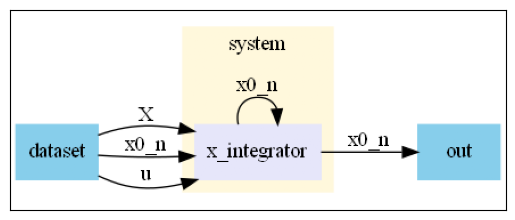

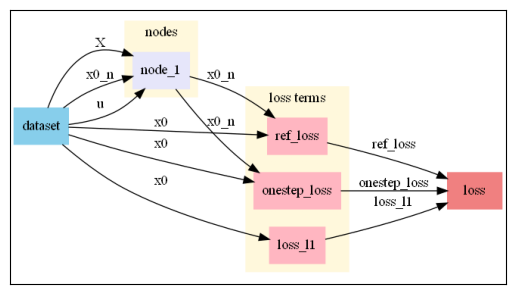

None
epoch: 0	train_loss: 0.52836	dev_loss: 0.49970	eltime:  0.99833
epoch: 100	train_loss: 0.00059	dev_loss: 0.00062	eltime:  13.25636
epoch: 200	train_loss: 0.00036	dev_loss: 0.00033	eltime:  26.54622
epoch: 300	train_loss: 0.00015	dev_loss: 0.00027	eltime:  39.30026
epoch: 400	train_loss: 0.00013	dev_loss: 0.00021	eltime:  52.25789
epoch: 500	train_loss: 0.00016	dev_loss: 0.00025	eltime:  65.20321
epoch: 600	train_loss: 0.00010	dev_loss: 0.00018	eltime:  77.99876

---------- Model 0 BEFORE pruning ----------
dx0/dt = -0.257*x0 + -0.179*x1 + -0.026*x0^2 + 0.366*x0*x1 + -0.055*x1^2 + -0.063*u_0 + -0.026*u_1 + 0.037*u_0*u_1 + -0.031*x0*u_0 + 0.324*x1*u_0 + -0.247*x0*u_1 + 0.181*x1*u_1 + 0.157*sqrt(x0) + 0.020*sqrt(x1) 

   Threshold=0.002  Active=14  (prev=14)
   Pruned terms: []

⇒ No change in active sets; coefficients kept.

---------- Model 0 AFTER pruning  ----------
dx0/dt = -0.257*x0 + -0.179*x1 + -0.026*x0^2 + 0.366*x0*x1 + -0.055*x1^2 + -0.063*u_0 + -0.026*u_1 + 0.037*u_0*u_1 

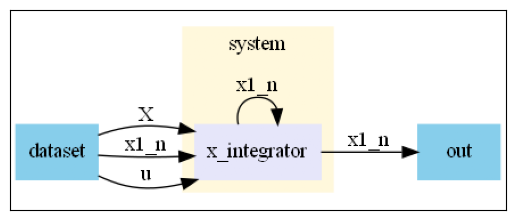

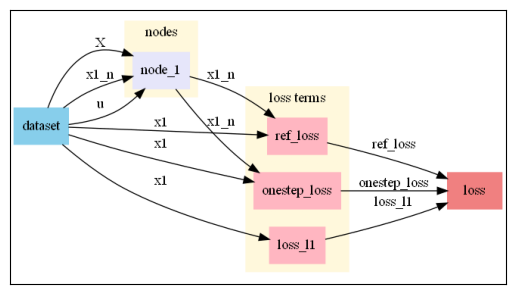

None
epoch: 0	train_loss: 2.01303	dev_loss: 3.53050	eltime:  0.72621
epoch: 100	train_loss: 0.00648	dev_loss: 0.00989	eltime:  9.71538
epoch: 200	train_loss: 0.00342	dev_loss: 0.00438	eltime:  18.46099
epoch: 300	train_loss: 0.00161	dev_loss: 0.00290	eltime:  27.42702
epoch: 400	train_loss: 0.00107	dev_loss: 0.00250	eltime:  36.27773
epoch: 500	train_loss: 0.00079	dev_loss: 0.00159	eltime:  45.14717
epoch: 600	train_loss: 0.00049	dev_loss: 0.00101	eltime:  53.90181

---------- Model 0 BEFORE pruning ----------
dx1/dt = -0.256*x1 + -0.292*x0 + -0.058*x0^2 + 0.455*x0*x1 + -0.018*x1^2 + -0.066*u_0 + -0.027*u_1 + 0.044*u_0*u_1 + -0.114*x0*u_0 + 0.434*x1*u_0 + -0.173*x0*u_1 + 0.251*x1*u_1 + 0.210*sqrt(x0) + -0.004*sqrt(x1) 

   Threshold=0.002  Active=14  (prev=14)
   Pruned terms: []

⇒ No change in active sets; coefficients kept.

---------- Model 0 AFTER pruning  ----------
dx1/dt = -0.256*x1 + -0.292*x0 + -0.058*x0^2 + 0.455*x0*x1 + -0.018*x1^2 + -0.066*u_0 + -0.027*u_1 + 0.044*u_0*u_1 

In [5]:
for i in range(nx):

    integrator_x = OneElementEulerIntegrator(fx_models[i], h=ts)
    integrator_node_x = Node(integrator_x, ['X', f'x{i}_n', 'u'], [f'x{i}_n'], name="x_integrator")
    dynamics_model_x = System([integrator_node_x])

    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Loss
    onestep_loss_x = 1.0 * ((x_hat[:, 1, :] == x[:, 1, :])^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = 5. *((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # Sparsity constraint
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = 1e-6 * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    lr = 1e-3
    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

    logger = BasicLogger(args=None, savedir='test', verbosity=100,
                    stdout=['dev_loss', 'train_loss'])
    epochs=7000

    trainer_x = SparseTrainer(
        problem      = problem_x,
        fx_models  = [fx_models[i]],      # list of SINDy models
        lr           = 1e-3,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=epochs,
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=0.002,
        prune_every=700,
        warmup=300,
        patience=50,
        threshold_mult=1.07,
        )
    for _ in range(1):
        # print(f'************   training with {nsteps} steps   ************   ')

        # Regenerate data for the new `nsteps`
        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x  # Keep the problem consistent

        # Train control policy
        best_model = trainer_x.train()


        trainer_x.model.load_state_dict(best_model)

        # Update step size
        nsteps *= 2
        # trainer.model.loss.objectives[2].weight *= 1.1
        dynamics_model_x.nsteps = nsteps



In [6]:
for fx in fx_models:
    print(fx)

dx0/dt = -0.039*sqrt(x0) + 0.078*u_0 + -0.078*u_0*u_1 

dx1/dt = 0.040*sqrt(x0) + -0.040*sqrt(x1) + 0.079*u_0*u_1 



In [7]:
integrator_x = FullStateEulerIntegrator(fx_models, ts)          # custom step
x_integrator_node= Node(integrator_x,['xn', 'u'], ['xn'], name=f"x_integrator")


sindy_system = System(
    [x_integrator_node],
    nsteps=nsteps
)

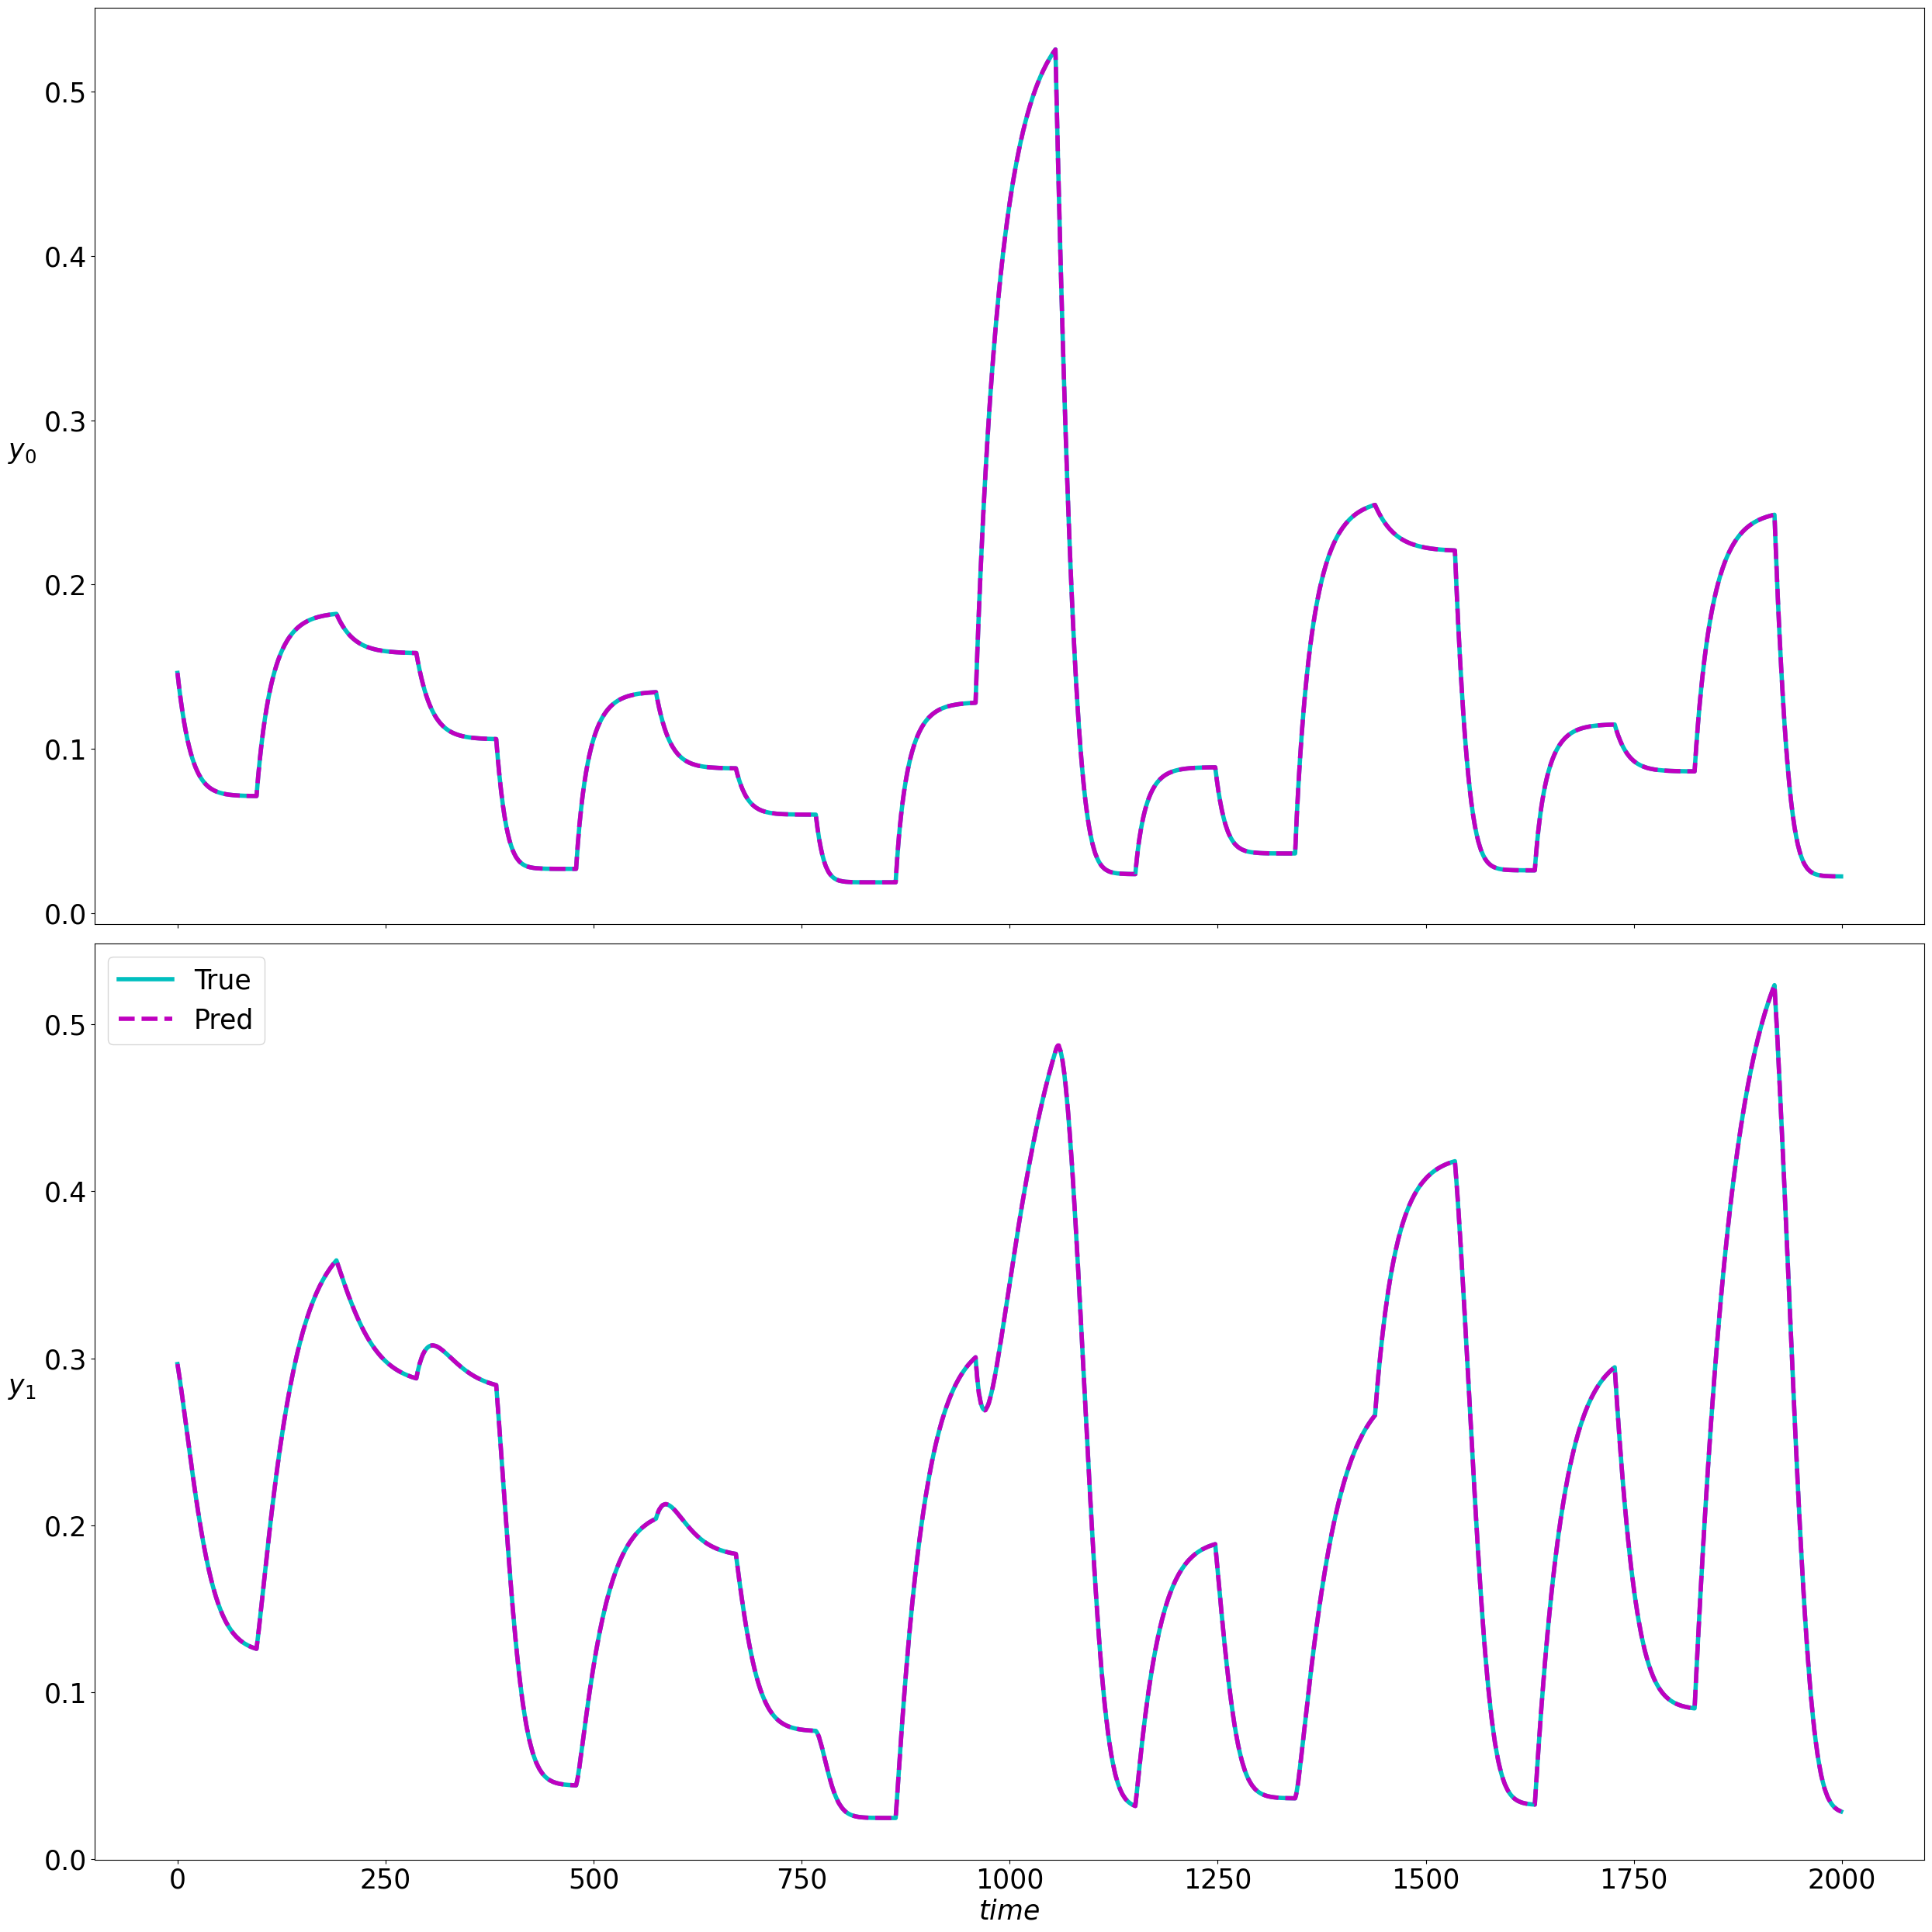

In [8]:
import matplotlib.pyplot as plt
sindy_system.nsteps = test_data['X'].shape[1]
test_output = sindy_system(test_data)

pred_traj = test_output['xn'][:, :-1, :]
true_traj = test_data['X']
pred_traj = pred_traj.detach().numpy().reshape(-1, nx)
true_traj = true_traj.detach().numpy().reshape(-1, nx)
pred_traj, true_traj = pred_traj.transpose(1, 0), true_traj.transpose(1, 0)

figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]
for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    if nx > 1:
        axe = ax[row]
    else:
        axe = ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)
axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()

#### Policy Training

In [9]:
import importlib
import SparseDPC.src.sindy.sindy  # Import the module itself
import SparseDPC.src.sindy.fx_library
import SparseDPC.src.data.getdata
import SparseDPC.src.trainer.trainer

importlib.reload(SparseDPC.src.sindy.fx_library )  # Reload the module
importlib.reload(SparseDPC.src.sindy.sindy )
importlib.reload(SparseDPC.src.data.getdata)
importlib.reload(SparseDPC.src.trainer.trainer)

from SparseDPC.src.sindy.sindy import SINDy
from SparseDPC.src.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.src.data.getdata import get_data, get_policy_data
from SparseDPC.src.trainer.trainer import SparseTrainer

In [28]:
nsteps = 50  # prediction horizon
n_samples = 2500    # number of sampled scenarios
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=5
                                           )

In [29]:
nsteps=50
policies_seed = 5
fx_policies = [fx_policy_library(nx=2, nref=1, policy_name= "p", seed=policies_seed, device=device),
               fx_policy_library(nx=2, nref=1, policy_name= "v", seed=policies_seed, device=device)]

for fp in fx_policies:
    print(fp)

p = 0.266*x_0 + -0.113*x_1 + 0.230*sin(x_0) + -0.314*sin(x_1) + 0.420*cos(x_0) + -0.050*cos(x_1) + -0.485*sin(2*x_0) + 0.104*sin(2*x_1) + -0.171*cos(2*x_0) + 0.105*cos(2*x_1) + -0.199*x_0*sin(x_0) + -0.383*x_1*sin(x_1) + 0.012*x_0*cos(x_0) + 0.454*x_1*cos(x_1) + 0.440*x_0 * x_1 + -0.268*r_0 + -0.374*cos(r_0) + -0.173*sin(r_0) + -0.062*cos(2*r_0) + -0.404*sin(2*r_0) + 0.460*x_0 * r_0 + -0.172*x_1 * r_0 + 0.498*x_0^2 * r_0 + -0.092*x_1^2 * r_0 + 0.486*x_0 * r_0^2 + -0.062*x_1 * r_0^2 

v = 0.266*x_0 + -0.113*x_1 + 0.230*sin(x_0) + -0.314*sin(x_1) + 0.420*cos(x_0) + -0.050*cos(x_1) + -0.485*sin(2*x_0) + 0.104*sin(2*x_1) + -0.171*cos(2*x_0) + 0.105*cos(2*x_1) + -0.199*x_0*sin(x_0) + -0.383*x_1*sin(x_1) + 0.012*x_0*cos(x_0) + 0.454*x_1*cos(x_1) + 0.440*x_0 * x_1 + -0.268*r_0 + -0.374*cos(r_0) + -0.173*sin(r_0) + -0.062*cos(2*r_0) + -0.404*sin(2*r_0) + 0.460*x_0 * r_0 + -0.172*x_1 * r_0 + 0.498*x_0^2 * r_0 + -0.092*x_1^2 * r_0 + 0.486*x_0 * r_0^2 + -0.062*x_1 * r_0^2 



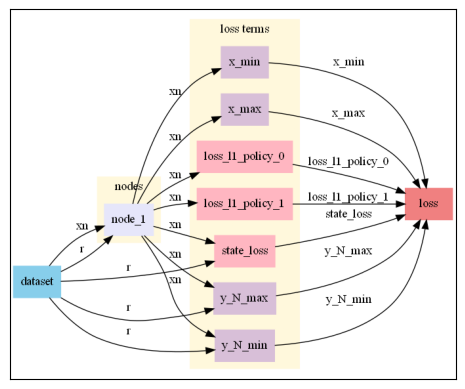

None
*** training with 50 steps ***
epoch: 0	train_loss: 5.72708	dev_loss: 5.78514	eltime:  14.51914
Training interrupted by user.
Policy 0:
p = 0.170*x_0 + -0.129*x_1 + 0.160*sin(x_0) + -0.303*sin(x_1) + 0.582*cos(x_0) + 0.090*cos(x_1) + -0.448*sin(2*x_0) + 0.199*sin(2*x_1) + 0.098*cos(2*x_0) + 0.384*cos(2*x_1) + -0.381*x_0*sin(x_0) + -0.471*x_1*sin(x_1) + 0.015*x_0*cos(x_0) + 0.526*x_1*cos(x_1) + 0.261*x_0 * x_1 + 0.036*r_0 + -0.359*cos(r_0) + 0.141*sin(r_0) + -0.529*cos(2*r_0) + -0.048*sin(2*r_0) + 0.465*x_0 * r_0 + -0.073*x_1 * r_0 + 0.327*x_0^2 * r_0 + -0.169*x_1^2 * r_0 + 0.464*x_0 * r_0^2 + -0.014*x_1 * r_0^2 


Policy 1:
v = 0.348*x_0 + -0.133*x_1 + 0.306*sin(x_0) + -0.324*sin(x_1) + 0.422*cos(x_0) + 0.060*cos(x_1) + -0.437*sin(2*x_0) + 0.139*sin(2*x_1) + -0.394*cos(2*x_0) + 0.263*cos(2*x_1) + -0.089*x_0*sin(x_0) + -0.431*x_1*sin(x_1) + 0.063*x_0*cos(x_0) + 0.469*x_1*cos(x_1) + 0.467*x_0 * x_1 + -0.286*r_0 + -0.281*cos(r_0) + -0.186*sin(r_0) + 0.235*cos(2*r_0) + -0.396*sin(2*r_

In [30]:
# ------------------------------------------------------------------ #
# 0.  Combined policy (any #policies)
# ------------------------------------------------------------------ #
policy_node = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax)  # capture fp by value
         for fp in fx_policies],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)

# ------------------------------------------------------------------ #
# build integrator node and system
# ------------------------------------------------------------------ #

integrator_x = FullStateEulerIntegrator(fx_models, ts)
x_integrator_node= Node(integrator_x,['xn', 'u'], ['xn'], name=f"x_integrator")
sindy_system = System(
    [policy_node, x_integrator_node],
    nsteps=nsteps
)

# ------------------------------------------------------------------ #
# 4.  Objectives
# ------------------------------------------------------------------ #
x   = variable('xn')
ref = variable('r')

regulation_loss      = 5.0 * ((x == ref) ^ 2); regulation_loss.name = "state_loss"

#   L1 sparsity for each policy
loss_l1_policies = []
for idx, fp in enumerate(fx_policies):
    l1_raw  = variable([x],
                       lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1),
                       display_name=f"l1_policy{idx}")
    l1_pen  = 1e-3 * (l1_raw == 0)
    l1_pen.name = f"loss_l1_policy_{idx}"
    loss_l1_policies.append(l1_pen)

# ------------------------------------------------------------------ #
# 5.  Constraints
# ------------------------------------------------------------------ #
state_lower  = 10.0 * (x > xmin);           state_lower.name  = "x_min"
state_upper  = 10.0 * (x < xmax);           state_upper.name  = "x_max"
term_lower   = 10.0 * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
term_upper   = 10.0 * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

# ------------------------------------------------------------------ #
# 6.  Problem definition
# ------------------------------------------------------------------ #
objectives  = [regulation_loss, *loss_l1_policies]
constraints = [state_lower, state_upper, term_lower, term_upper]

loss     = PenaltyLoss(objectives, constraints)
problem  = Problem([sindy_system], loss)
problem.show()

# ------------------------------------------------------------------ #
# 7.  Optimiser & trainer
# ------------------------------------------------------------------ #
lr         = 0.008
optimizers = [torch.optim.AdamW(fp.parameters(), lr=lr) for fp in fx_policies]

trainer_policy = SparseTrainer(
    problem     = problem,
    fx_models   = fx_policies,
    lr          = lr,
    train_data  = train_loader,
    dev_data    = dev_loader,
    optimizers  = optimizers,
    epochs      = 1200,
    train_metric='train_loss',
    eval_metric ='dev_loss',
    logger      = BasicLogger(args=None, savedir='test', verbosity=10,
                              stdout=['dev_loss', 'train_loss']),
    device      = device,
    threshold   = 0.20,
    prune_every = 100,
    threshold_mult=1.11
)

print(f"*** training with {nsteps} steps ***")
best_state = trainer_policy.train()
trainer_policy.model.load_state_dict(best_state)

for i, fp in enumerate(fx_policies):
    print(f"Policy {i}:\n{fp}\n")


In [31]:
for fp in fx_policies:
    print(fp)

p = 0.170*x_0 + -0.129*x_1 + 0.160*sin(x_0) + -0.303*sin(x_1) + 0.582*cos(x_0) + 0.090*cos(x_1) + -0.448*sin(2*x_0) + 0.199*sin(2*x_1) + 0.098*cos(2*x_0) + 0.384*cos(2*x_1) + -0.381*x_0*sin(x_0) + -0.471*x_1*sin(x_1) + 0.015*x_0*cos(x_0) + 0.526*x_1*cos(x_1) + 0.261*x_0 * x_1 + 0.036*r_0 + -0.359*cos(r_0) + 0.141*sin(r_0) + -0.529*cos(2*r_0) + -0.048*sin(2*r_0) + 0.465*x_0 * r_0 + -0.073*x_1 * r_0 + 0.327*x_0^2 * r_0 + -0.169*x_1^2 * r_0 + 0.464*x_0 * r_0^2 + -0.014*x_1 * r_0^2 

v = 0.348*x_0 + -0.133*x_1 + 0.306*sin(x_0) + -0.324*sin(x_1) + 0.422*cos(x_0) + 0.060*cos(x_1) + -0.437*sin(2*x_0) + 0.139*sin(2*x_1) + -0.394*cos(2*x_0) + 0.263*cos(2*x_1) + -0.089*x_0*sin(x_0) + -0.431*x_1*sin(x_1) + 0.063*x_0*cos(x_0) + 0.469*x_1*cos(x_1) + 0.467*x_0 * x_1 + -0.286*r_0 + -0.281*cos(r_0) + -0.186*sin(r_0) + 0.235*cos(2*r_0) + -0.396*sin(2*r_0) + 0.493*x_0 * r_0 + -0.231*x_1 * r_0 + 0.569*x_0^2 * r_0 + -0.163*x_1^2 * r_0 + 0.496*x_0 * r_0^2 + -0.135*x_1 * r_0^2 



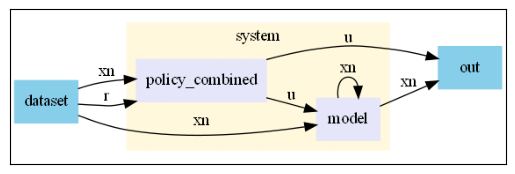

In [25]:
# white-box
# ODE model with no-plant model mismatch
two_tank = ode.TwoTankParam()                   # ODE system equations implemented in PyTorch
two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)
# integrate continuous time ODE
gt_integrator = integrators.Euler(two_tank, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

import copy
gt_sindy_policy = copy.deepcopy(System([policy_node,
                       gt_integrator_node]))
gt_sindy_policy.show()

(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

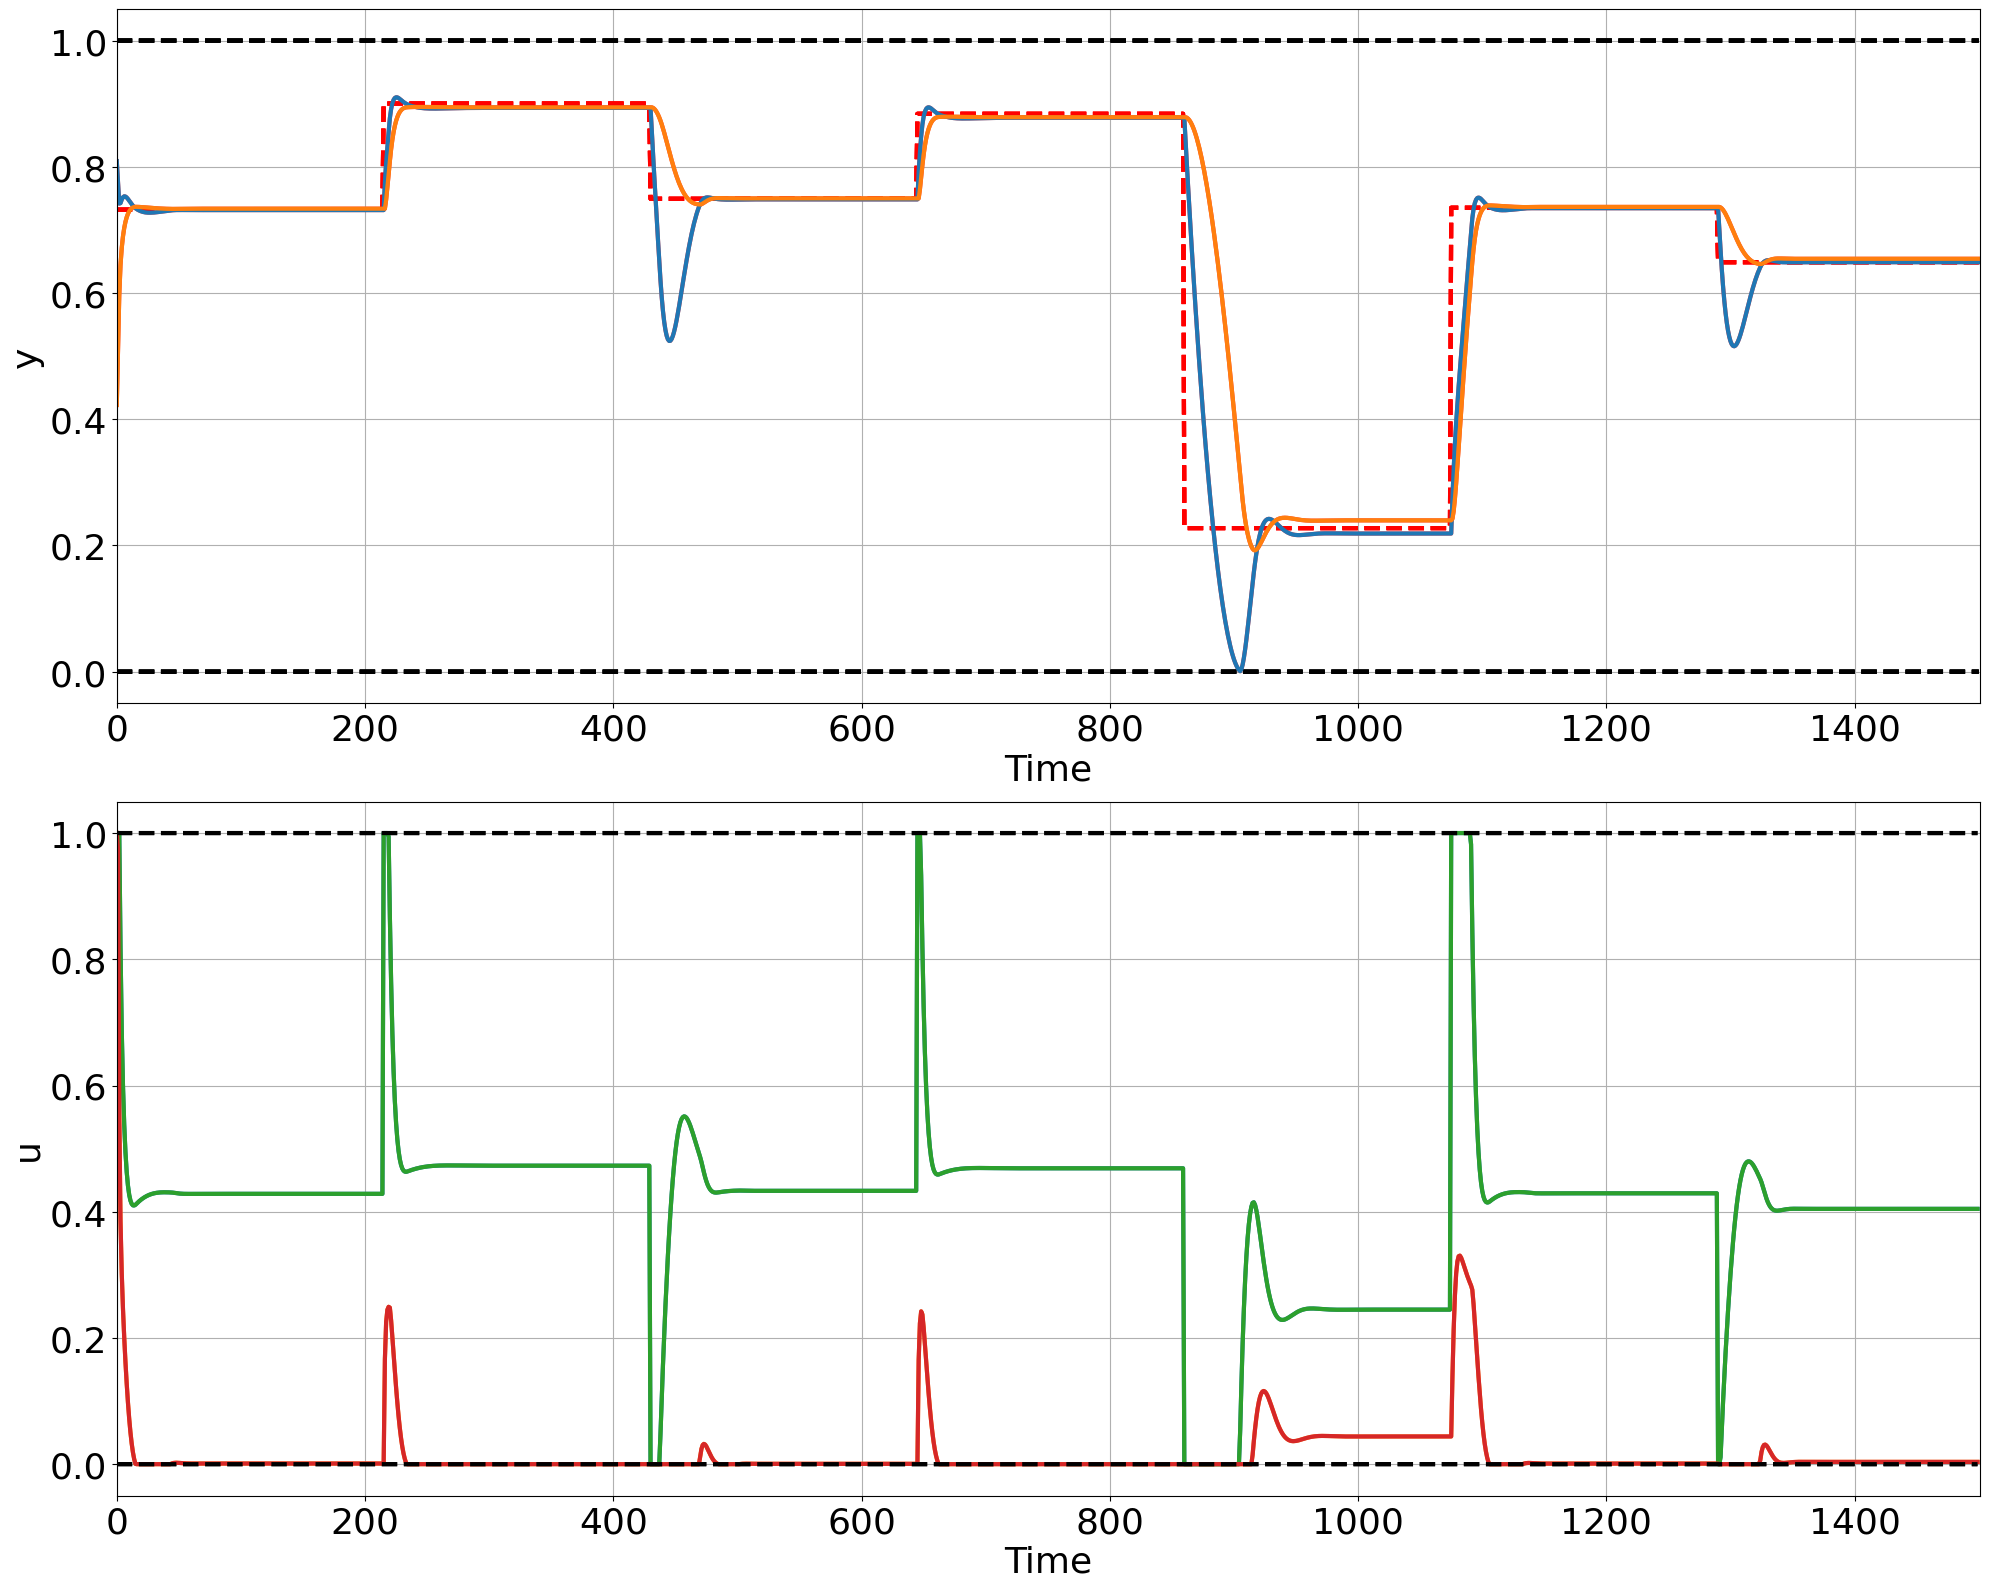

In [27]:
import numpy as np
from neuromancer.plot import pltCL, pltPhase

nsteps = 1500
torch.manual_seed(63)
seed = 84
rng = np.random.default_rng(seed)
# generate reference
np_refs = psl.signals.step(nsteps+1, 1, min=xmin, max=xmax, randsteps=7, rng=rng)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)
x_sample = torch.rand(1, 1, nx, dtype=torch.float32)
data = {'xn': x_sample,
        'x0_n': x_sample[:,:,0:1],
        'x1_n': x_sample[:,:,1:2],
        'r': torch_ref}

sindy_system.nsteps = nsteps
# perform closed-loop simulation
trajectories = sindy_system(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories['xn'].detach().cpu().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().cpu().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().cpu().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

### Sparse Policy with Whitebox model

In [389]:
nsteps=50
fx_policies_wb = [fx_policy_library(nx=2, nref=1, policy_name= "p", seed=policies_seed),
               fx_policy_library(nx=2, nref=1, policy_name= "v", seed=policies_seed)]

for fp in fx_policies_wb:
    print(fp)

p = 0.330*x_0 + -0.374*x_1 + 0.407*sin(x_0) + 0.320*sin(x_1) + 0.420*cos(x_0) + -0.383*cos(x_1) + -0.336*sin(2*x_0) + 0.238*sin(2*x_1) + -0.467*cos(2*x_0) + 0.494*cos(2*x_1) + 0.106*x_0*sin(x_0) + 0.065*x_1*sin(x_1) + -0.428*x_0*cos(x_0) + 0.159*x_1*cos(x_1) + 0.215*x_0 * x_1 + 0.079*r_0 + 0.481*cos(r_0) + 0.150*sin(r_0) + -0.443*cos(2*r_0) + 0.420*sin(2*r_0) + 0.170*x_0 * r_0 + -0.239*x_1 * r_0 + -0.459*x_0^2 * r_0 + 0.285*x_1^2 * r_0 + 0.475*x_0 * r_0^2 + -0.410*x_1 * r_0^2 

v = 0.330*x_0 + -0.374*x_1 + 0.407*sin(x_0) + 0.320*sin(x_1) + 0.420*cos(x_0) + -0.383*cos(x_1) + -0.336*sin(2*x_0) + 0.238*sin(2*x_1) + -0.467*cos(2*x_0) + 0.494*cos(2*x_1) + 0.106*x_0*sin(x_0) + 0.065*x_1*sin(x_1) + -0.428*x_0*cos(x_0) + 0.159*x_1*cos(x_1) + 0.215*x_0 * x_1 + 0.079*r_0 + 0.481*cos(r_0) + 0.150*sin(r_0) + -0.443*cos(2*r_0) + 0.420*sin(2*r_0) + 0.170*x_0 * r_0 + -0.239*x_1 * r_0 + -0.459*x_0^2 * r_0 + 0.285*x_1^2 * r_0 + 0.475*x_0 * r_0^2 + -0.410*x_1 * r_0^2 



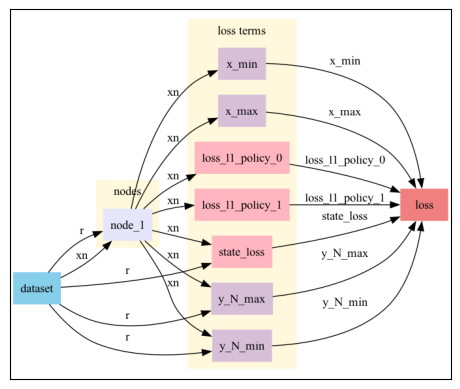

None
*** training with 50 steps ***
epoch: 0	train_loss: 0.93425	dev_loss: 1.15937	eltime:  1.80039
epoch: 10	train_loss: 0.32976	dev_loss: 0.40372	eltime:  18.53261
epoch: 20	train_loss: 0.28849	dev_loss: 0.35593	eltime:  37.77728
epoch: 30	train_loss: 0.26670	dev_loss: 0.33141	eltime:  56.33548
epoch: 40	train_loss: 0.25446	dev_loss: 0.31717	eltime:  75.91553
epoch: 50	train_loss: 0.24655	dev_loss: 0.30785	eltime:  95.17588
epoch: 60	train_loss: 0.24116	dev_loss: 0.30212	eltime:  114.84217
epoch: 70	train_loss: 0.23758	dev_loss: 0.29804	eltime:  134.17451
epoch: 80	train_loss: 0.23479	dev_loss: 0.29497	eltime:  154.55289
epoch: 90	train_loss: 0.23283	dev_loss: 0.29247	eltime:  174.53782

---------- Model 0 BEFORE pruning ----------
p = 0.106*x_0 + -0.527*x_1 + 0.199*sin(x_0) + 0.060*sin(x_1) + 0.359*cos(x_0) + -0.378*cos(x_1) + -0.321*sin(2*x_0) + -0.020*sin(2*x_1) + 0.057*cos(2*x_0) + 0.984*cos(2*x_1) + -0.372*x_0*sin(x_0) + -0.186*x_1*sin(x_1) + -0.442*x_0*cos(x_0) + -0.080*x_1*cos

In [390]:
# ------------------------------------------------------------------ #
# 0.  Combined policy (any #policies)
# ------------------------------------------------------------------ #
policy_node_wb = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax)  # capture fp by value
         for fp in fx_policies_wb],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)


sindy_system_wb = System(
    [policy_node_wb, gt_integrator_node],
    nsteps=nsteps
)

# ------------------------------------------------------------------ #
# 4.  Objectives
# ------------------------------------------------------------------ #
x_wb   = variable('xn')
ref_wb = variable('r')

regulation_loss_wb      = 5.0 * ((x == ref) ^ 2); regulation_loss_wb.name = "state_loss"

#  L1 sparsity for each policy
loss_l1_policies = []
for idx, fp in enumerate(fx_policies_wb):
    l1_raw  = variable([x],
                       lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1),
                       display_name=f"l1_policy{idx}")
    l1_pen  = 0.001 * (l1_raw == 0)
    l1_pen.name = f"loss_l1_policy_{idx}"
    loss_l1_policies.append(l1_pen)

# ------------------------------------------------------------------ #
# 5.  Constraints
# ------------------------------------------------------------------ #
state_lower  = 10.0 * (x > xmin);           state_lower.name  = "x_min"
state_upper  = 10.0 * (x < xmax);           state_upper.name  = "x_max"
term_lower   = 10.0 * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
term_upper   = 10.0 * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

# ------------------------------------------------------------------ #
# 6.  Problem definition
# ------------------------------------------------------------------ #
objectives  = [regulation_loss, *loss_l1_policies]
constraints = [state_lower, state_upper, term_lower, term_upper]

loss     = PenaltyLoss(objectives, constraints)
problem_wb  = Problem([sindy_system_wb], loss)
problem_wb.show()

# ------------------------------------------------------------------ #
# 7.  Optimiser & trainer
# ------------------------------------------------------------------ #
lr         = 0.008
optimizers_wb = [torch.optim.AdamW(fp.parameters(), lr=lr) for fp in fx_policies_wb]

trainer_policy_wb = SparseTrainer(
    problem     = problem_wb,
    fx_models   = fx_policies_wb,
    lr          = lr,
    train_data  = train_loader,
    dev_data    = dev_loader,
    optimizers  = optimizers_wb,
    epochs      = 1200,
    train_metric='train_loss',
    eval_metric ='dev_loss',
    logger      = BasicLogger(args=None, savedir='test', verbosity=10,
                              stdout=['dev_loss', 'train_loss']),
    device      = device,
    threshold   = 0.20,
    prune_every = 100,
    threshold_mult=1.11
)

print(f"*** training with {nsteps} steps ***")
best_state = trainer_policy_wb.train()
trainer_policy_wb.model.load_state_dict(best_state)

for i, fp in enumerate(fx_policies_wb):
    print(f"Policy {i}:\n{fp}\n")


(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

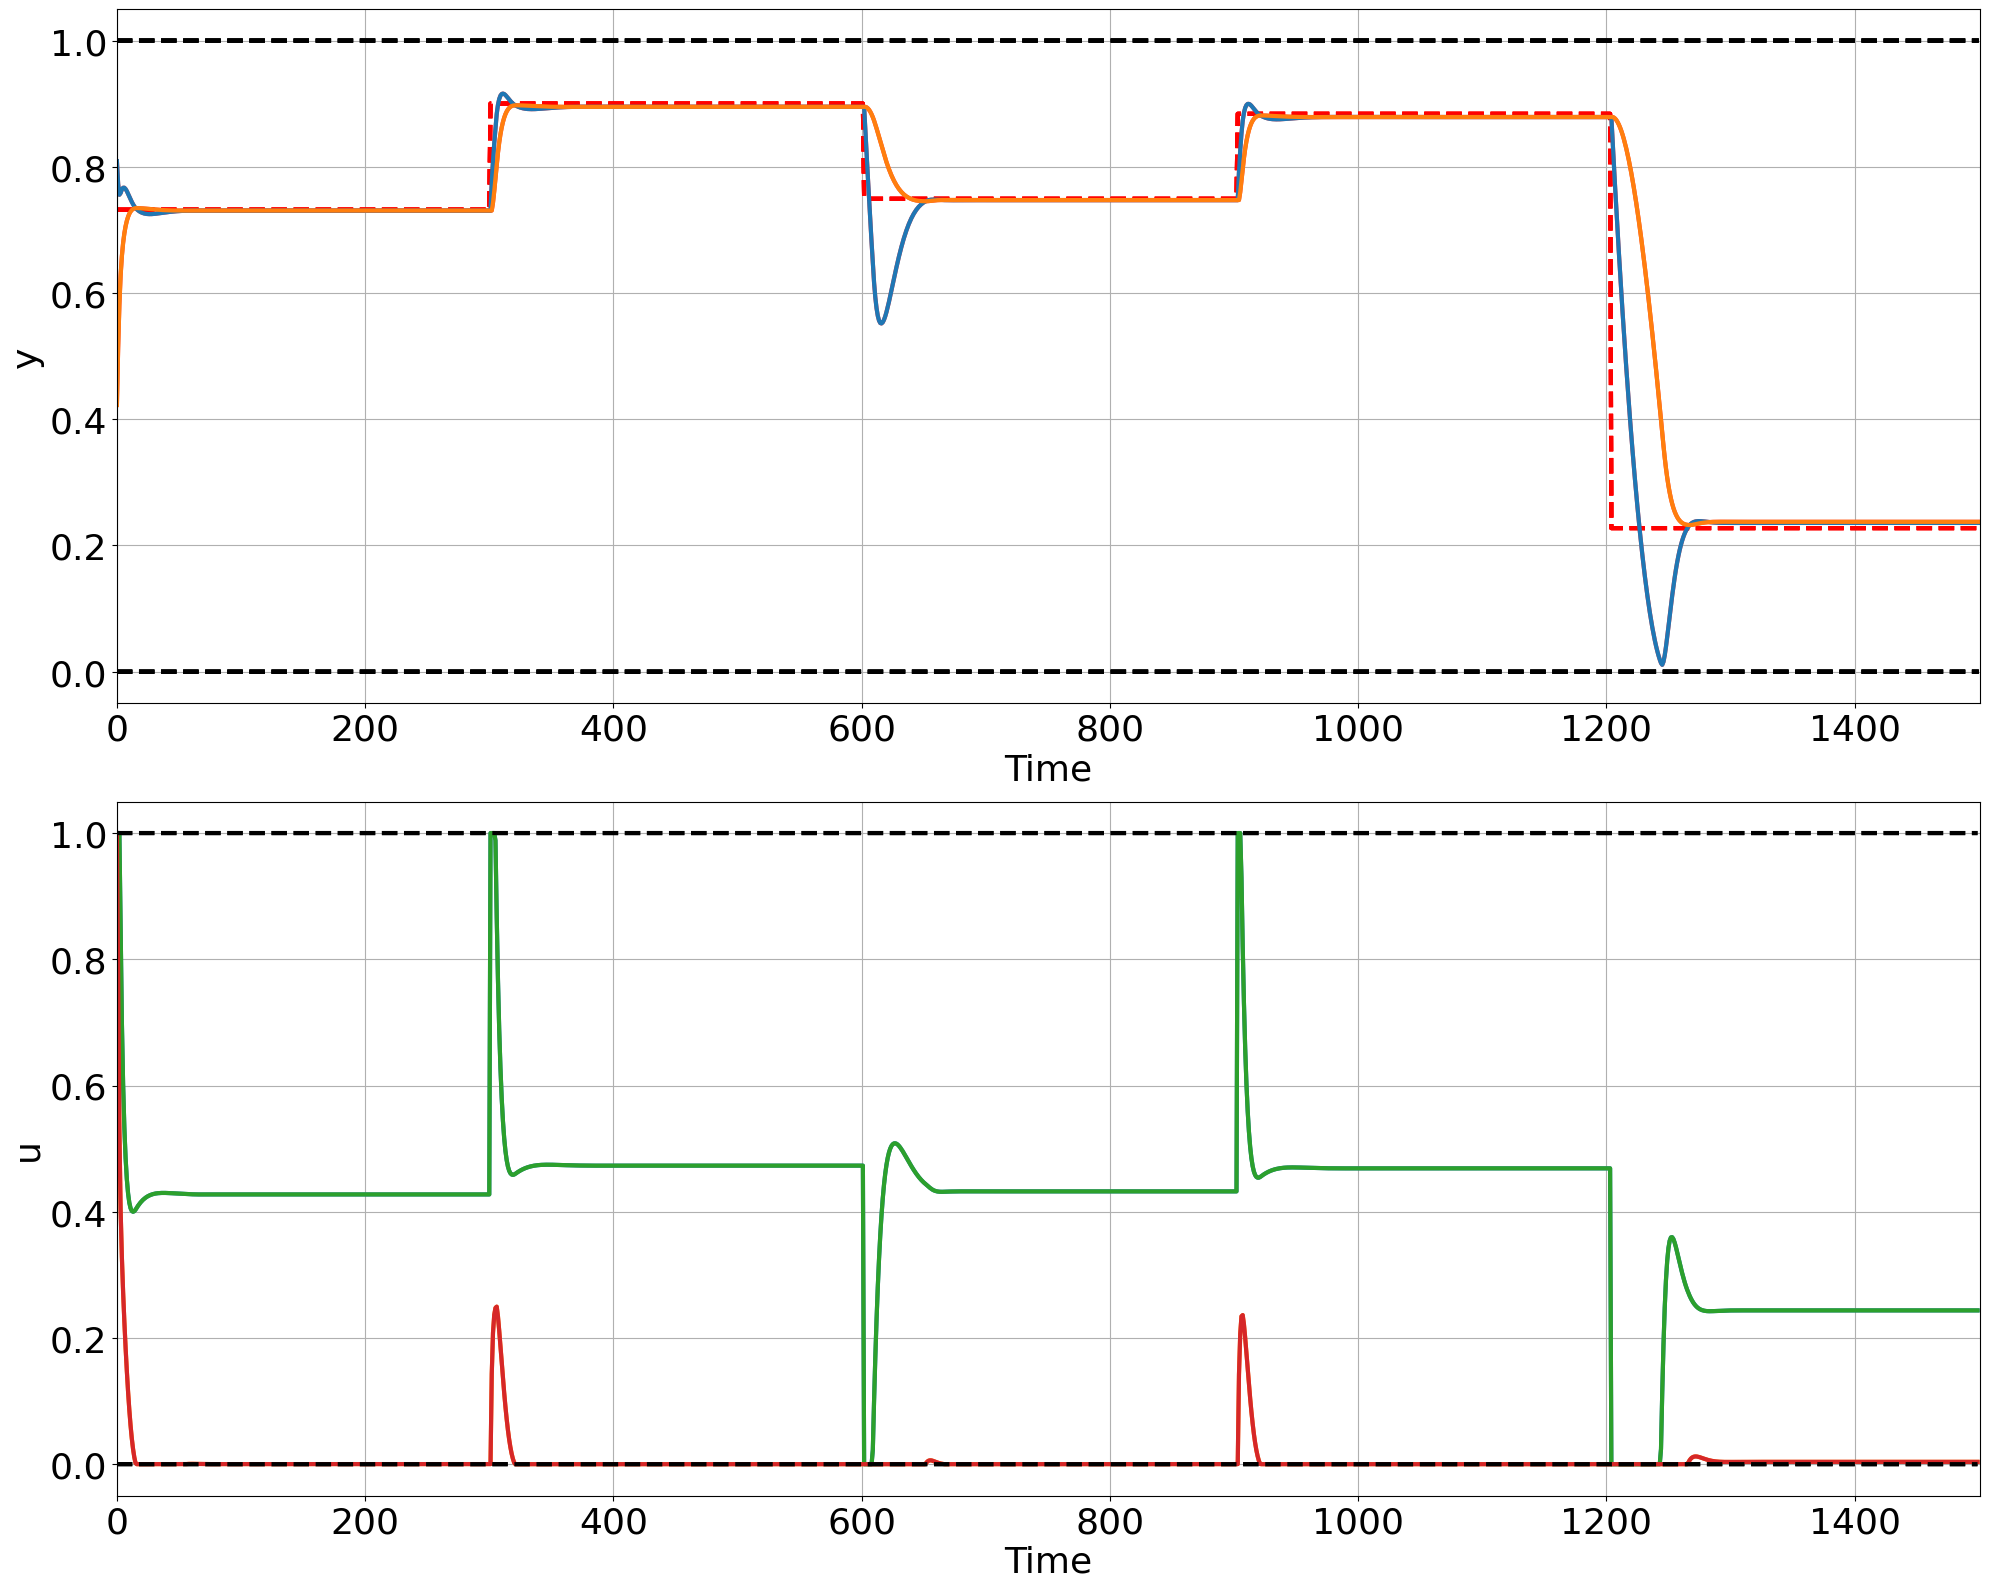

In [391]:
import numpy as np
from neuromancer.plot import pltCL, pltPhase

nsteps = 1500
torch.manual_seed(63)
seed = 84
rng = np.random.default_rng(seed)
# generate reference
np_refs = psl.signals.step(nsteps+1, 1, min=xmin, max=xmax, randsteps=5, rng=rng)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)
x_sample = torch.rand(1, 1, nx, dtype=torch.float32)
data = {'xn': x_sample,
        'x0_n': x_sample[:,:,0:1],
        'x1_n': x_sample[:,:,1:2],
        'r': torch_ref}

sindy_system_wb.nsteps = nsteps
# perform closed-loop simulation
trajectories = sindy_system_wb(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories['xn'].detach().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

In [392]:
for i, fp in enumerate(fx_policies):
    print(f"Policy {i}:\n{fp}\n")

Policy 0:
p = -1.748*x_1 + -0.813*sin(2*x_0) + 1.908*cos(2*x_1) + -1.176*x_0*sin(x_0) + 1.477*r_0 + 0.554*sin(r_0) + -1.822*cos(2*r_0) + 1.278*sin(2*r_0) + 0.897*x_1^2 * r_0 


Policy 1:
v = -1.557*cos(2*x_0) + 1.567*cos(2*x_1) 




In [393]:
for i, fp in enumerate(fx_policies_wb):
    print(f"Policy {i}:\n{fp}\n")

Policy 0:
p = -1.671*x_1 + -0.759*sin(2*x_0) + 1.879*cos(2*x_1) + -1.216*x_0*sin(x_0) + 1.293*r_0 + 0.961*sin(r_0) + -1.797*cos(2*r_0) + 1.078*sin(2*r_0) + 0.820*x_1^2 * r_0 


Policy 1:
v = -1.564*cos(2*x_0) + 1.571*cos(2*x_1) 


